#DATA

In [2]:
pip install lingam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.1/103.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 3.7 MB/s eta 0:00:00
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659681 sha256=d72e7623ad2c9abb2ab3f44986cce42095de467e50ac285a3c6885d49f59d2ae
  Stored in directory: /root/.cache/pip/wheels/d2/9a/31/fae291ff6a649bad125037eef8c7cc63d8c542e14bdcccea37
Successfully built semopy
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import numpy as np
import pandas as pd
import sys
import os
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.preprocessing import LabelEncoder
import re
from math import sqrt
import lingam
from lingam import DirectLiNGAM
from lingam.utils import make_dot, make_prior_knowledge
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [5]:
ITMO_data = pd.read_csv('/content/drive/MyDrive/НИР/ITMO production data.csv')

rename_dict = {
    "datetime": "date",
    "Номер скважины": "cat",
    "Дебит нефти": "oil",
    "Дебит газа (ТМ)": "gas",
    "Дебит жидкости (ТМ)": "liquid",
    "Давление забойное": "bhp",
}

ITMO_data.rename(columns=rename_dict, inplace=True)

ITMO_data["cat"] = "p_" + ITMO_data["cat"].astype(str)

coords_df = ITMO_data.filter(["cat", "x", "y"]).drop_duplicates().reset_index(drop=True)
ITMO_data.drop(columns=["x", "y"], inplace=True)

ITMO_data["group"] = "P"
ITMO_data["choke"] = np.where(ITMO_data["liquid"] == 0, 0, 1)

display(ITMO_data.head())
display(ITMO_data.info())

,date,cat,oil,bhp,Объем жидкости,Объем нефти,Активная мощность (ТМ),Время работы (ТМ),Газовый фактор рабочий (ТМ),Давление буферное,Давление забойное от Hд,Давление забойное от Pпр,Давление линейное (ТМ),Давление на входе ЭЦН (ТМ),gas,Дебит газа попутного,liquid,Коэффициент мощности (ТМ),group,choke
0,1990-08-01,p_0,19.939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P,1
1,1990-08-02,p_0,19.939,39.064454,NaN,NaN,50.851351,9.600833,NaN,NaN,33.913336,39.064454,1.887872,30.293676,3843.746667,24.25,24.250000,98.534314,P,1
2,1990-08-03,p_0,21.172,39.064487,NaN,NaN,52.353846,NaN,NaN,NaN,33.806090,39.064487,1.885714,30.261774,3900.955000,25.75,25.833333,99.139785,P,1
3,1990-08-04,p_0,22.529,38.965297,NaN,NaN,51.242424,9.600000,NaN,NaN,33.695717,38.965297,1.875851,30.212768,3874.505000,27.40,27.933333,98.744318,P,1
4,1990-08-05,p_0,22.529,38.766822,NaN,NaN,50.910256,9.563889,NaN,NaN,33.695717,38.766822,1.873163,30.109119,3853.696667,27.40,27.400000,98.419689,P,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67136 entries, 0 to 67135
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   date                         67136 non-null  object 
 1   cat                          67136 non-null  object 
 2   oil                          67136 non-null  float64
 3   bhp                          64756 non-null  float64
 4   Объем жидкости               3465 non-null   float64
 5   Объем нефти                  3465 non-null   float64
 6   Активная мощность (ТМ)       62412 non-null  float64
 7   Время работы (ТМ)            63475 non-null  float64
 8   Газовый фактор рабочий (ТМ)  25230 non-null  float64
 9   Давление буферное            10208 non-null  float64
 10  Давление забойное от Hд      65710 non-null  float64
 11  Давление забойное от Pпр     42297 non-null  float64
 12  Давление линейное (ТМ)       66796 non-null  float64
 13  Давление на вход

None

In [6]:
coords_df.head(10)

,cat,x,y
0,p_0,18670.86,5714.86
1,p_1,19964.69,10000.63
2,p_2,20541.78,9806.47
3,p_3,12578.90,7805.61
4,p_4,9828.65,18016.98
5,p_5,18713.19,9731.53
6,p_6,12146.24,22686.24
7,p_7,9427.28,18515.75
8,p_8,19494.13,8660.68
9,p_9,13713.11,6761.05


In [7]:
ITMO_wells = pd.merge(ITMO_data, coords_df, on="cat", how="left")
display(ITMO_wells.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67136 entries, 0 to 67135
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   date                         67136 non-null  object 
 1   cat                          67136 non-null  object 
 2   oil                          67136 non-null  float64
 3   bhp                          64756 non-null  float64
 4   Объем жидкости               3465 non-null   float64
 5   Объем нефти                  3465 non-null   float64
 6   Активная мощность (ТМ)       62412 non-null  float64
 7   Время работы (ТМ)            63475 non-null  float64
 8   Газовый фактор рабочий (ТМ)  25230 non-null  float64
 9   Давление буферное            10208 non-null  float64
 10  Давление забойное от Hд      65710 non-null  float64
 11  Давление забойное от Pпр     42297 non-null  float64
 12  Давление линейное (ТМ)       66796 non-null  float64
 13  Давление на вход

None

In [8]:
COSTA_data = pd.read_csv('/content/drive/MyDrive/НИР/COSTA well_heads.csv')
COSTA_data.drop(
    columns=["Unnamed: 0", "Z_top", "Z_bottom", "YEAR", "KB", "TD", "TYPE"],
    inplace=True,
)

rename_dict = {"WELLNAME": "cat", "X": "x", "Y": "y"}
COSTA_data.rename(columns=rename_dict, inplace=True)

display(COSTA_data.head())
display(COSTA_data.info())


,cat,x,y
0,Inj-1,49374.998177,75374.998596
1,Inj-2,49374.998177,77874.996691
2,Inj-3,54374.999129,75374.998596
3,Inj-4,54374.999129,77874.996691
4,Inj-5,44374.998415,75374.998596


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 430 entries, 0 to 429
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cat     430 non-null    object 
 1   x       430 non-null    float64
 2   y       430 non-null    float64
dtypes: float64(2), object(1)
memory usage: 10.2+ KB


None

In [21]:
data = pd.DataFrame()

sheet_names = [
    "Appraisal Wells",
    "Production Wells",
    "Peripheral Water Injectors",
    "Infill Water Injectors",
]

df = pd.read_excel('/content/drive/MyDrive/НИР/COSTA Synthetic Production Monthly.xlsx', sheet_name=sheet_names, header=4)

df.dropna(axis=1, how="all", inplace=True)
data = pd.DataFrame(df)
data.columns = [col.lower() for col in data.columns]

#data = data.rename('well':'well', 'date':'date', 'water rate sc - monthly (bbl/day)' : 'gor', )
data.head()


SyntaxError: invalid syntax (<ipython-input-21-ca7aaabf5e91>, line 16)

In [20]:
COSTA_data = COSTA_data.rename(columns={'cat': 'well', 'x':'X', 'y':'Y'})
COSTA_data.head()
COSTA_wells = pd.merge(data, COSTA_data, on = 'well', how='left')
COSTA_wells.head()

KeyError: 'well'

In [9]:
volve_df = pd.read_excel('/content/drive/MyDrive/НИР/Volve production data.xlsx', sheet_name="Daily Production Data")
volve_df.dropna(axis=1, how="all", inplace=True)
volve_df.columns = [col.lower() for col in volve_df.columns]

drop_cols = [c for c in list(volve_df) if volve_df[c].nunique() <= 1]


volve_df.drop(columns=drop_cols, inplace=True)
volve_df.head()


,dateprd,well_bore_code,npd_well_bore_code,npd_well_bore_name,on_stream_hrs,avg_downhole_pressure,avg_downhole_temperature,avg_dp_tubing,avg_annulus_press,avg_choke_size_p,avg_whp_p,avg_wht_p,dp_choke_size,bore_oil_vol,bore_gas_vol,bore_wat_vol,bore_wi_vol,flow_kind,well_type
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,0.0,0.00000,0.00000,0.00000,0.0,0.000000,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,1.003059,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,0.979008,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,0.545759,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,0.0,310.37614,96.87589,277.27826,0.0,1.215987,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


In [ ]:
volve_df["npd_well_bore_name"].unique()

array(['15/9-F-1 C', '15/9-F-11', '15/9-F-12', '15/9-F-14', '15/9-F-15 D',
       '15/9-F-4', '15/9-F-5', '15/9-F-15'], dtype=object)

In [ ]:
d = {
    "15/9-F-4": (435654.01, 6477677.22),
    "15/9-F-5": (436403.89, 6478703.6),
    "15/9-F-14": (436028.94, 6478876.54),
    "15/9-F-1 C": (435584.78, 6479497.27),
    "15/9-F-11": (436551.57, 6478399.73),
    "15/9-F-12": (435335.51, 6478201.54),
    "15/9-F-15 D": (436650.23, 6478716.35),
    # "15/9-F-15": (434105.85, 6476758.93),
}
df = pd.DataFrame.from_dict(d).T
df.reset_index(inplace=True)
df.columns = ["NPD_WELL_BORE_NAME", "x", "y"]

df["cat"] = df["NPD_WELL_BORE_NAME"]

df.drop(columns=["NPD_WELL_BORE_NAME"], inplace=True)


df.to_csv("coords_volve.csv", index=False)

df

,x,y,cat
0,435654.01,6477677.22,15/9-F-4
1,436403.89,6478703.60,15/9-F-5
2,436028.94,6478876.54,15/9-F-14
3,435584.78,6479497.27,15/9-F-1 C
4,436551.57,6478399.73,15/9-F-11
5,435335.51,6478201.54,15/9-F-12
6,436650.23,6478716.35,15/9-F-15 D


In [ ]:
for col in ["choke", "oil", "water"]:
    data[col] = np.where(data["cat"] == "15/9-F-5", np.nan, data[col])

data["water"] = np.where(data["water"] < 0, np.nan, data["water"])

KeyError: 'cat'

In [ ]:
display(itmo_df.head())
display(costa_df.head())
display(volve_df.head())

,datetime,Номер скважины,Дебит нефти,Давление забойное,x,y,Объем жидкости,Объем нефти,Активная мощность (ТМ),Время работы (ТМ),Газовый фактор рабочий (ТМ),Давление буферное,Давление забойное от Hд,Давление забойное от Pпр,Давление линейное (ТМ),Давление на входе ЭЦН (ТМ),Дебит газа (ТМ),Дебит газа попутного,Дебит жидкости (ТМ),Коэффициент мощности (ТМ)
0,1990-08-01,0,19.939,NaN,18670.86,5714.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1990-08-02,0,19.939,39.064454,18670.86,5714.86,NaN,NaN,50.851351,9.600833,NaN,NaN,33.913336,39.064454,1.887872,30.293676,3843.746667,24.25,24.250000,98.534314
2,1990-08-03,0,21.172,39.064487,18670.86,5714.86,NaN,NaN,52.353846,NaN,NaN,NaN,33.806090,39.064487,1.885714,30.261774,3900.955000,25.75,25.833333,99.139785
3,1990-08-04,0,22.529,38.965297,18670.86,5714.86,NaN,NaN,51.242424,9.600000,NaN,NaN,33.695717,38.965297,1.875851,30.212768,3874.505000,27.40,27.933333,98.744318
4,1990-08-05,0,22.529,38.766822,18670.86,5714.86,NaN,NaN,50.910256,9.563889,NaN,NaN,33.695717,38.766822,1.873163,30.109119,3853.696667,27.40,27.400000,98.419689


,Unnamed: 0,WELLNAME,X,Y,Z_top,Z_bottom,YEAR,TYPE,KB,TD
0,0,Inj-1,49374.998177,75374.998596,7688.272461,7786.164185,2025,injector,0,10000
1,1,Inj-2,49374.998177,77874.996691,7626.077271,7719.181396,2025,injector,0,10000
2,2,Inj-3,54374.999129,75374.998596,7999.930298,8081.996826,2026,injector,0,10000
3,3,Inj-4,54374.999129,77874.996691,7896.249878,7976.912231,2026,injector,0,10000
4,4,Inj-5,44374.998415,75374.998596,7472.895630,7577.164551,2027,injector,0,10000


,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


#Data Analytics

In [8]:
display(ITMO_wells.head())
display(ITMO_wells.info())

,date,cat,oil,bhp,Объем жидкости,Объем нефти,Активная мощность (ТМ),Время работы (ТМ),Газовый фактор рабочий (ТМ),Давление буферное,...,Давление линейное (ТМ),Давление на входе ЭЦН (ТМ),gas,Дебит газа попутного,liquid,Коэффициент мощности (ТМ),group,choke,x,y
0,1990-08-01,p_0,19.939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,P,1,18670.86,5714.86
1,1990-08-02,p_0,19.939,39.064454,NaN,NaN,50.851351,9.600833,NaN,NaN,...,1.887872,30.293676,3843.746667,24.25,24.250000,98.534314,P,1,18670.86,5714.86
2,1990-08-03,p_0,21.172,39.064487,NaN,NaN,52.353846,NaN,NaN,NaN,...,1.885714,30.261774,3900.955000,25.75,25.833333,99.139785,P,1,18670.86,5714.86
3,1990-08-04,p_0,22.529,38.965297,NaN,NaN,51.242424,9.600000,NaN,NaN,...,1.875851,30.212768,3874.505000,27.40,27.933333,98.744318,P,1,18670.86,5714.86
4,1990-08-05,p_0,22.529,38.766822,NaN,NaN,50.910256,9.563889,NaN,NaN,...,1.873163,30.109119,3853.696667,27.40,27.400000,98.419689,P,1,18670.86,5714.86


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67136 entries, 0 to 67135
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   date                         67136 non-null  object 
 1   cat                          67136 non-null  object 
 2   oil                          67136 non-null  float64
 3   bhp                          64756 non-null  float64
 4   Объем жидкости               3465 non-null   float64
 5   Объем нефти                  3465 non-null   float64
 6   Активная мощность (ТМ)       62412 non-null  float64
 7   Время работы (ТМ)            63475 non-null  float64
 8   Газовый фактор рабочий (ТМ)  25230 non-null  float64
 9   Давление буферное            10208 non-null  float64
 10  Давление забойное от Hд      65710 non-null  float64
 11  Давление забойное от Pпр     42297 non-null  float64
 12  Давление линейное (ТМ)       66796 non-null  float64
 13  Давление на вход

None

In [9]:
ITMO_wells['date']= pd.to_datetime(ITMO_wells['date'])

In [10]:
display(ITMO_wells['cat'].unique())
display(ITMO_wells['group'].unique())
display(ITMO_wells['choke'].unique())

array(['p_0', 'p_1', 'p_2', 'p_3', 'p_4', 'p_5', 'p_6', 'p_7', 'p_8',
       'p_9', 'p_10', 'p_11', 'p_12', 'p_13', 'p_14', 'p_15', 'p_16',
       'p_17', 'p_18', 'p_19', 'p_20', 'p_21', 'p_22', 'p_23', 'p_24',
       'p_25', 'p_26', 'p_27', 'p_28', 'p_29', 'p_30', 'p_31', 'p_32',
       'p_33', 'p_34', 'p_35', 'p_36', 'p_37', 'p_38', 'p_39', 'p_40',
       'p_41', 'p_42', 'p_43', 'p_44', 'p_45', 'p_46', 'p_47', 'p_48',
       'p_49', 'p_50', 'p_51', 'p_52', 'p_53', 'p_54', 'p_55', 'p_56',
       'p_57', 'p_58', 'p_59', 'p_60', 'p_61', 'p_62', 'p_63', 'p_64',
       'p_65', 'p_66', 'p_67', 'p_68', 'p_69', 'p_70', 'p_71', 'p_72',
       'p_73', 'p_74', 'p_75', 'p_76', 'p_77', 'p_78', 'p_79', 'p_80',
       'p_81', 'p_82', 'p_83', 'p_84', 'p_85', 'p_86', 'p_87', 'p_88',
       'p_89', 'p_90', 'p_91', 'p_92', 'p_93', 'p_94', 'p_95', 'p_96',
       'p_97', 'p_98', 'p_99', 'p_100', 'p_101', 'p_102', 'p_103',
       'p_104', 'p_105'], dtype=object)

array(['P'], dtype=object)

array([1])

In [11]:
#Энкодинг
df_encoded = ITMO_wells.copy()

# Функция кодирования с сохранением NaN
def encode_with_nan(df, column):
    le = LabelEncoder()
    mask = df[column].notna()
    df.loc[mask, column] = le.fit_transform(df.loc[mask, column])
    return le

le_well_name = encode_with_nan(df_encoded, 'cat')
le_choke = encode_with_nan(df_encoded, 'choke')


display(df_encoded.info())
display(df_encoded.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67136 entries, 0 to 67135
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         67136 non-null  datetime64[ns]
 1   cat                          67136 non-null  object        
 2   oil                          67136 non-null  float64       
 3   bhp                          64756 non-null  float64       
 4   Объем жидкости               3465 non-null   float64       
 5   Объем нефти                  3465 non-null   float64       
 6   Активная мощность (ТМ)       62412 non-null  float64       
 7   Время работы (ТМ)            63475 non-null  float64       
 8   Газовый фактор рабочий (ТМ)  25230 non-null  float64       
 9   Давление буферное            10208 non-null  float64       
 10  Давление забойное от Hд      65710 non-null  float64       
 11  Давление забойное от Pпр     42297 non-nu

None

,date,cat,oil,bhp,Объем жидкости,Объем нефти,Активная мощность (ТМ),Время работы (ТМ),Газовый фактор рабочий (ТМ),Давление буферное,...,Давление линейное (ТМ),Давление на входе ЭЦН (ТМ),gas,Дебит газа попутного,liquid,Коэффициент мощности (ТМ),group,choke,x,y
0,1990-08-01,0,19.939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,P,0,18670.86,5714.86
1,1990-08-02,0,19.939,39.064454,NaN,NaN,50.851351,9.600833,NaN,NaN,...,1.887872,30.293676,3843.746667,24.25,24.250000,98.534314,P,0,18670.86,5714.86
2,1990-08-03,0,21.172,39.064487,NaN,NaN,52.353846,NaN,NaN,NaN,...,1.885714,30.261774,3900.955000,25.75,25.833333,99.139785,P,0,18670.86,5714.86
3,1990-08-04,0,22.529,38.965297,NaN,NaN,51.242424,9.600000,NaN,NaN,...,1.875851,30.212768,3874.505000,27.40,27.933333,98.744318,P,0,18670.86,5714.86
4,1990-08-05,0,22.529,38.766822,NaN,NaN,50.910256,9.563889,NaN,NaN,...,1.873163,30.109119,3853.696667,27.40,27.400000,98.419689,P,0,18670.86,5714.86


##Analytics

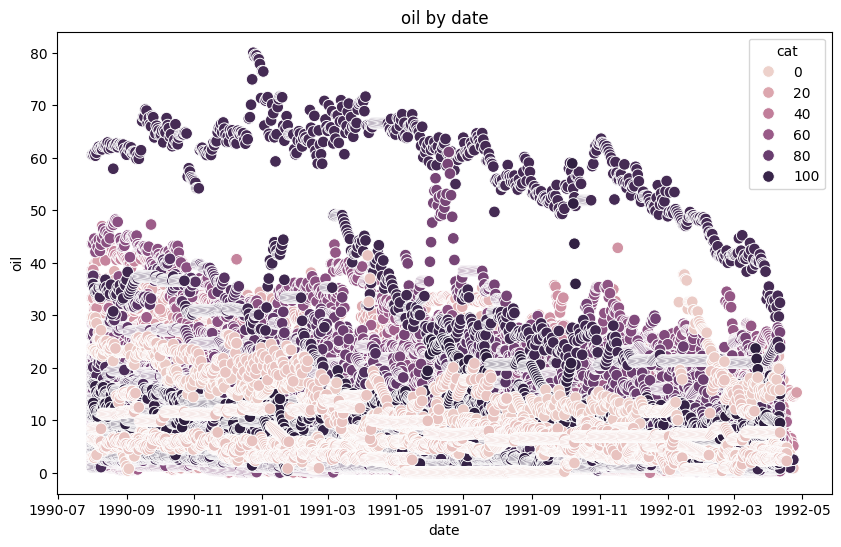

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="date", y="oil", hue="cat", data=df_encoded, s=70).set_title('oil by date')
plt.show()

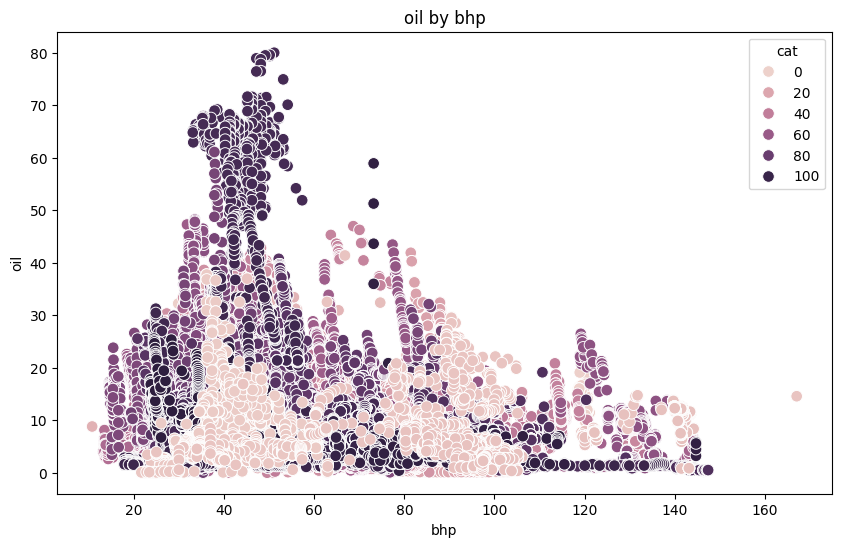

In [30]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="bhp", y="oil", hue="cat", data=df_encoded, s=70).set_title('oil by bhp')
plt.show()

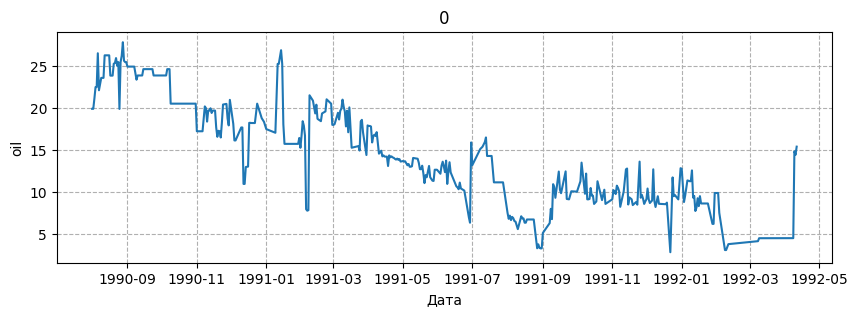

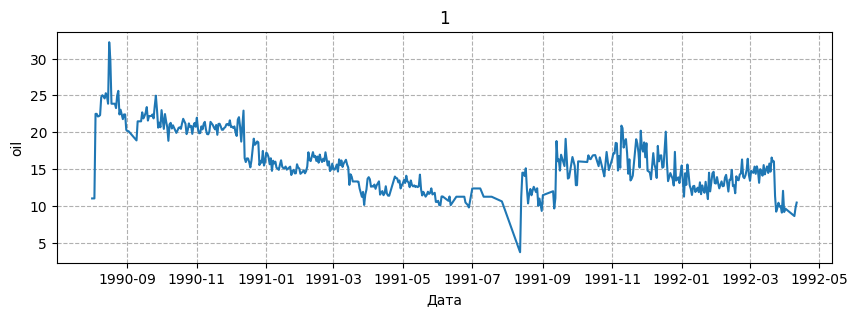

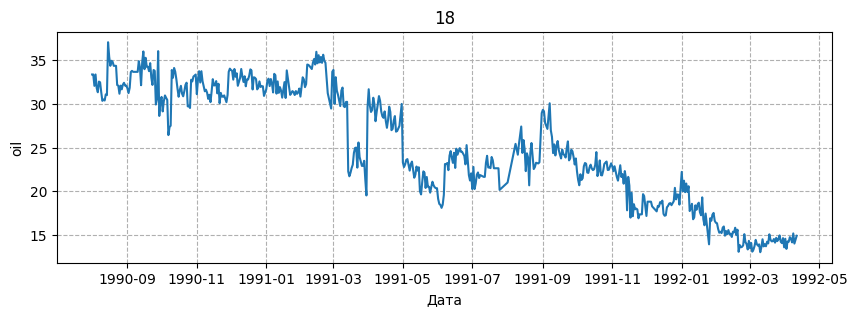

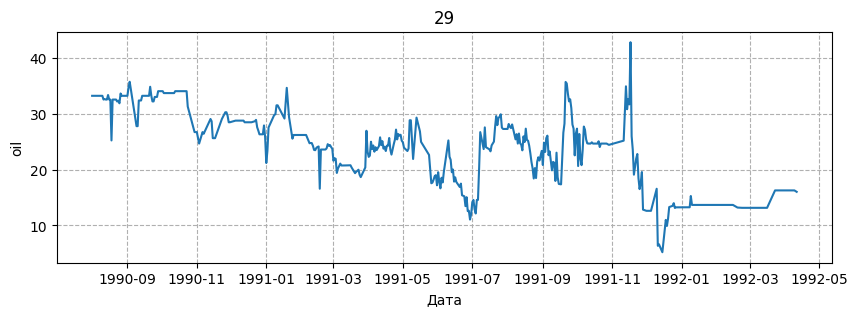

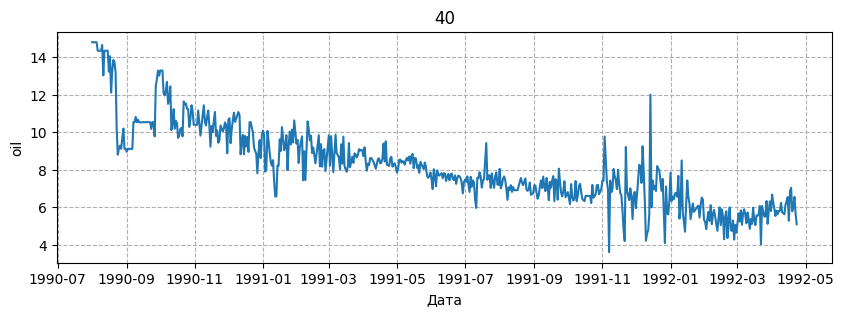

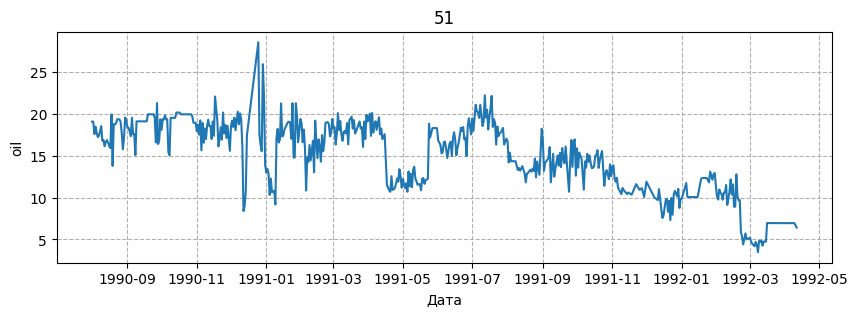

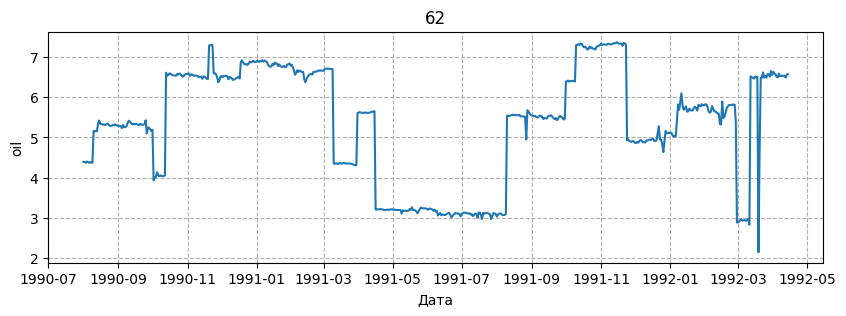

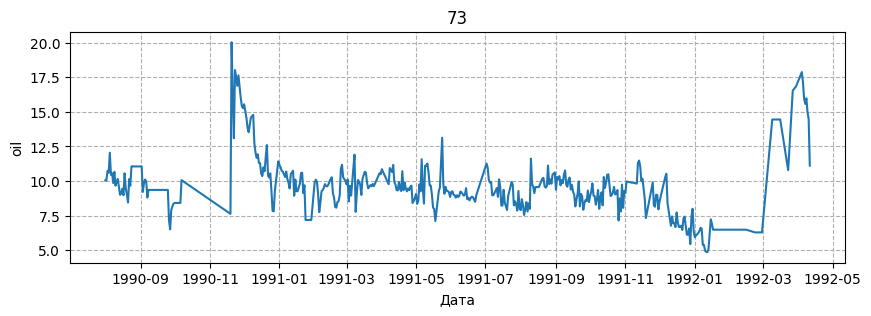

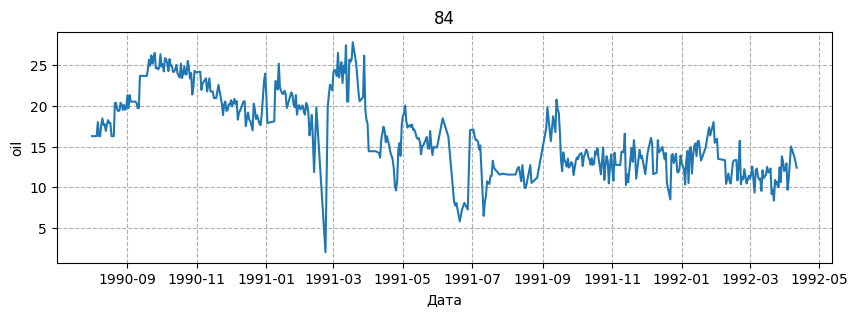

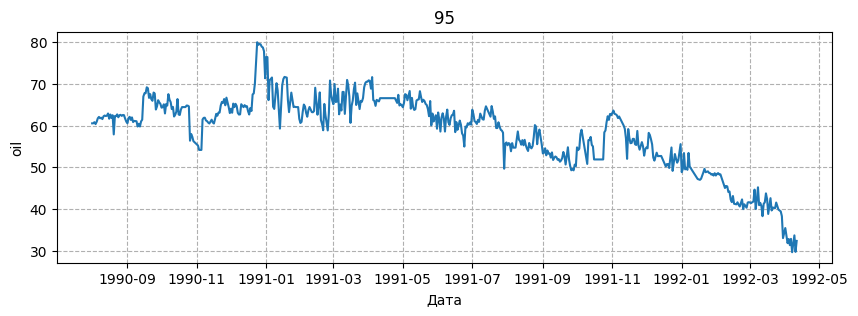

In [ ]:
#Временной ряд добычи нефти

param = "oil"

for well in df_encoded["cat"].unique()[:10]:
    tmp = df_encoded[df_encoded["cat"] == well]
    plt.figure(figsize=(10, 3))

    plt.plot(tmp["date"], tmp[param])
    plt.grid(ls="--")
    plt.title(well)
    plt.xlabel("Дата")
    plt.ylabel(param)

In [12]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67136 entries, 0 to 67135
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         67136 non-null  datetime64[ns]
 1   cat                          67136 non-null  object        
 2   oil                          67136 non-null  float64       
 3   bhp                          64756 non-null  float64       
 4   Объем жидкости               3465 non-null   float64       
 5   Объем нефти                  3465 non-null   float64       
 6   Активная мощность (ТМ)       62412 non-null  float64       
 7   Время работы (ТМ)            63475 non-null  float64       
 8   Газовый фактор рабочий (ТМ)  25230 non-null  float64       
 9   Давление буферное            10208 non-null  float64       
 10  Давление забойное от Hд      65710 non-null  float64       
 11  Давление забойное от Pпр     42297 non-nu

In [13]:
le_date = encode_with_nan(df_encoded, 'date')

<ipython-input-11-f4aea6686e13>:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[  0   1   2 ... 617 618 619]' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.loc[mask, column] = le.fit_transform(df.loc[mask, column])


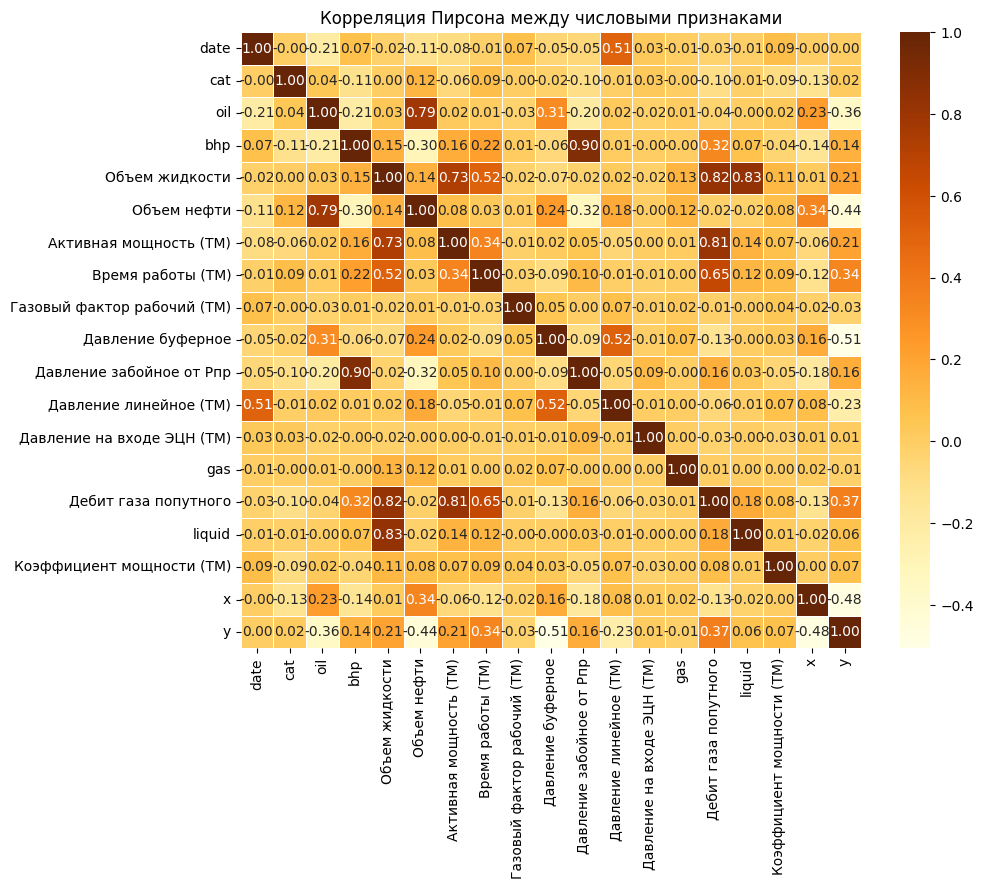

In [14]:
# Корреляция Пирсона для числовых признаков
pearson_corr = df_encoded[['date', 'cat', 'oil', 'bhp', 'Объем жидкости', 'Объем нефти', 'Активная мощность (ТМ)', 'Время работы (ТМ)', 'Газовый фактор рабочий (ТМ)', 'Давление буферное', 'Давление забойное от Pпр', 'Давление линейное (ТМ)', 'Давление на входе ЭЦН (ТМ)', 'gas', 'Дебит газа попутного', 'liquid', 'Коэффициент мощности (ТМ)', 'x', 'y']].corr(method='pearson')

# Построим heatmap для корреляции Пирсона
plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, cmap='YlOrBr', fmt='.2f', linewidths=0.5)
plt.title('Корреляция Пирсона между числовыми признаками')
plt.show()

In [15]:
df_encoded.fillna(0)

<ipython-input-15-096c0a96e572>:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded.fillna(0)


,date,cat,oil,bhp,Объем жидкости,Объем нефти,Активная мощность (ТМ),Время работы (ТМ),Газовый фактор рабочий (ТМ),Давление буферное,...,Давление линейное (ТМ),Давление на входе ЭЦН (ТМ),gas,Дебит газа попутного,liquid,Коэффициент мощности (ТМ),group,choke,x,y
0,0,0,19.939,0.000000,0.000,0.000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,P,0,18670.86,5714.86
1,1,0,19.939,39.064454,0.000,0.000,50.851351,9.600833,0.0,0.0,...,1.887872,30.293676,3843.746667,24.25,24.250000,98.534314,P,0,18670.86,5714.86
2,2,0,21.172,39.064487,0.000,0.000,52.353846,0.000000,0.0,0.0,...,1.885714,30.261774,3900.955000,25.75,25.833333,99.139785,P,0,18670.86,5714.86
3,3,0,22.529,38.965297,0.000,0.000,51.242424,9.600000,0.0,0.0,...,1.875851,30.212768,3874.505000,27.40,27.933333,98.744318,P,0,18670.86,5714.86
4,4,0,22.529,38.766822,0.000,0.000,50.910256,9.563889,0.0,0.0,...,1.873163,30.109119,3853.696667,27.40,27.400000,98.419689,P,0,18670.86,5714.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67131,615,8,7.646,122.180672,0.000,0.000,252.298969,24.000000,0.0,0.0,...,11.548286,20.536082,0.000000,451.36,451.358333,72.876289,P,0,14230.22,22456.04
67132,616,8,7.639,122.182381,15472.802,161.526,251.647423,24.000000,0.0,0.0,...,11.556784,20.459184,0.000000,450.97,450.972727,72.855670,P,0,14230.22,22456.04
67133,617,8,7.657,122.183551,0.000,0.000,251.713542,24.000000,0.0,13.0,...,11.583542,20.104167,0.000000,452.03,452.027273,72.302083,P,0,14230.22,22456.04
67134,618,8,7.654,122.180372,0.000,0.000,251.504167,24.000000,0.0,0.0,...,11.601396,20.052083,0.000000,451.85,451.850000,72.041667,P,0,14230.22,22456.04


In [16]:
rename_dict = {
    'date': 'date',
    'cat': 'well',
    'oil': 'oil',
    'bhp': 'bhp',
    'Объем жидкости': 'water_volume',
    'Объем нефти': 'oil_volume',
    'Активная мощность (ТМ)': 'active_power',
    'Время работы (ТМ)': 'active_time',
    'Газовый фактор рабочий (ТМ)': 'gas_working_factor',
    'Давление буферное': 'buffer_pressure',
    'Давление забойное от Pпр': 'bottom_hole_pressure_from_rpr',
    'Давление забойное от Hд':'bottom_hole_pressure_from_nd',
    'Давление линейное (ТМ)': 'linear_pressure',
    'Давление на входе ЭЦН (ТМ)': 'pressure_at_the_inlet_of_the_ecn',
    'gas': 'gas',
    'Дебит газа попутного': 'associated_gas_flow_rate',
    'liquid':'liquid',
    'Коэффициент мощности (ТМ)': 'power_factor',
    'group': 'group',
    'choke':'choke',
    'x': 'x',
    'y': 'y'
}
df_encoded.rename(columns=rename_dict, inplace=True)
df_encoded.head()
df_encoded['bottom_hole_pressure_from_nd']

,bottom_hole_pressure_from_nd
0,NaN
1,33.913336
2,33.806090
3,33.695717
4,33.695717
...,...
67131,122.180672
67132,122.182381
67133,122.183551
67134,122.180372


In [46]:
model_1 = smf.ols('oil ~ bhp + liquid + water_volume + oil_volume + active_power + active_time + gas_working_factor + buffer_pressure + bottom_hole_pressure_from_rpr + bottom_hole_pressure_from_nd + linear_pressure + pressure_at_the_inlet_of_the_ecn + associated_gas_flow_rate + power_factor', data=df_encoded).fit()
model_1.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,11.9249,0.144,82.768,0.000,11.643,12.207
bhp,-0.0379,0.002,-18.981,0.000,-0.042,-0.034
liquid,4.557e-05,0.000,0.427,0.670,-0.000,0.000
water_volume,-0.0011,8.26e-05,-13.353,0.000,-0.001,-0.001
oil_volume,0.0131,0.000,31.216,0.000,0.012,0.014
active_power,0.0131,0.001,11.280,0.000,0.011,0.015
active_time,0.0978,0.006,16.834,0.000,0.086,0.109
gas_working_factor,-3.691e-06,1.03e-06,-3.596,0.000,-5.7e-06,-1.68e-06
buffer_pressure,0.0711,0.005,14.105,0.000,0.061,0.081
bottom_hole_pressure_from_rpr,0.0189,0.001,16.020,0.000,0.017,0.021


In [47]:
(df_encoded
 .groupby('buffer_pressure')
 ["oil"]
 .mean())

,oil
buffer_pressure,
0.000000,10.723134
4.500000,17.880214
5.000000,6.506212
5.500000,9.443421
5.666667,12.211000
...,...
32.000000,14.962000
33.000000,20.938923
35.000000,15.308000


In [48]:
X = df_encoded[["associated_gas_flow_rate"]].assign(intercep = 1)
y = df_encoded["oil"]

def regress(y, X):
    return np.linalg.inv(X.T.dot(X)).dot(X.T.dot(y))

beta = regress(y, X)
beta

array([-1.12559578e-03,  1.08398585e+01])

In [49]:
#Находим CI с привязкой к скважинам
X = df_encoded.drop(columns = ['date','group', 'x', 'y', 'choke', 'gas', 'gas_working_factor', 'pressure_at_the_inlet_of_the_ecn'])
df_encoded.fillna(0, inplace=True)
print(X.shape)
X.head(10)

(67136, 14)


,well,oil,bhp,water_volume,oil_volume,active_power,active_time,buffer_pressure,bottom_hole_pressure_from_nd,bottom_hole_pressure_from_rpr,linear_pressure,associated_gas_flow_rate,liquid,power_factor
0,0,19.939,0.000000,0.000,0.000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00,0.000000,0.000000
1,0,19.939,39.064454,0.000,0.000,50.851351,9.600833,0.0,33.913336,39.064454,1.887872,24.25,24.250000,98.534314
2,0,21.172,39.064487,0.000,0.000,52.353846,0.000000,0.0,33.806090,39.064487,1.885714,25.75,25.833333,99.139785
3,0,22.529,38.965297,0.000,0.000,51.242424,9.600000,0.0,33.695717,38.965297,1.875851,27.40,27.933333,98.744318
4,0,22.529,38.766822,0.000,0.000,50.910256,9.563889,0.0,33.695717,38.766822,1.873163,27.40,27.400000,98.419689
5,0,26.558,39.064668,0.000,0.000,52.773333,9.536389,0.0,33.394049,39.064668,1.895426,32.30,33.200000,98.827411
6,0,22.150,39.367223,0.000,0.000,52.766234,9.500000,0.0,33.947313,39.367223,1.914947,30.00,37.933333,98.981395
7,0,22.888,39.367223,788.311,757.568,52.759036,9.600278,0.0,33.947313,39.367223,1.906082,0.00,40.700000,98.847619
8,0,23.626,39.268002,0.000,0.000,49.012821,9.649722,0.0,33.833863,39.268002,1.898506,32.00,36.433333,98.254054
9,0,23.626,39.367282,0.000,0.000,53.192308,9.600833,0.0,33.833863,39.367282,1.897708,32.00,27.233333,99.130000


In [50]:
pk = make_prior_knowledge(
    n_variables=len(X.columns),
    sink_variables=[1])

Causal order of variables: ['oil_volume', 'water_volume', 'buffer_pressure', 'associated_gas_flow_rate', 'linear_pressure', 'power_factor', 'well', 'bottom_hole_pressure_from_rpr', 'active_time', 'liquid', 'bhp', 'active_power', 'bottom_hole_pressure_from_nd', 'oil']

Adjacency Matrix:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00 -3.73412989e-02
   0.00000000e+00 -6.39652457e-02]
 [ 5.30295345e-03  0.00000000e+00 -3.73035853e-02 -1.09651853e-03
   1.31402378e-02  1.31116974e-02  9.34502298e-02  7.09918289e-02
  -5.02180179e-02  1.92569482e-02  2.84153828e-02 -2.65444217e-03
   0.00000000e+00  9.78589111e-03]
 [-5.96173186e-02  0.00000000e+00  0.00000000e+00  1.54288657e-03
  -7.40654654e-03  0.00000000e+00  7.07531618e-01  0.00000000e+00
   0.00000000e+00  3.74491998e-01  7.00881660e-02  5.53464074e-02
   1.07594491e-03 -1.70427036e-02]
 [ 0.00000000e

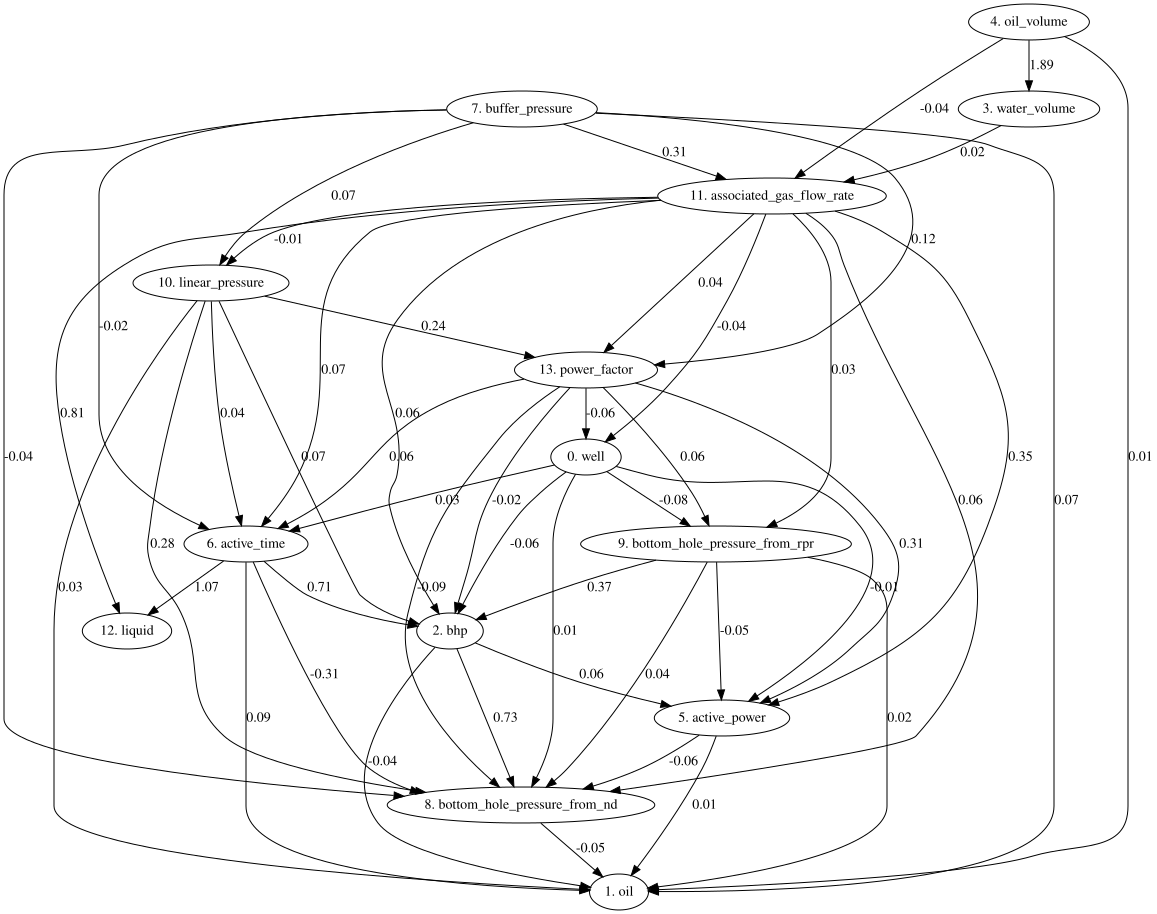

In [51]:
# Строим модель LiNGAM
model = lingam.DirectLiNGAM(prior_knowledge= pk)
model.fit(X)
# Получение порядка переменных (порядка причинности)
order = model.causal_order_
print(f"Causal order of variables: {X.columns[order].to_list()}")

# Получение матрицы смежности
adjacency_matrix = model.adjacency_matrix_
print("\nAdjacency Matrix:")
print(adjacency_matrix)
labels = [f'{i}. {col}' for i, col in enumerate(X.columns)]
graph = make_dot(model.adjacency_matrix_, labels)
matplotlib.pyplot.savefig()

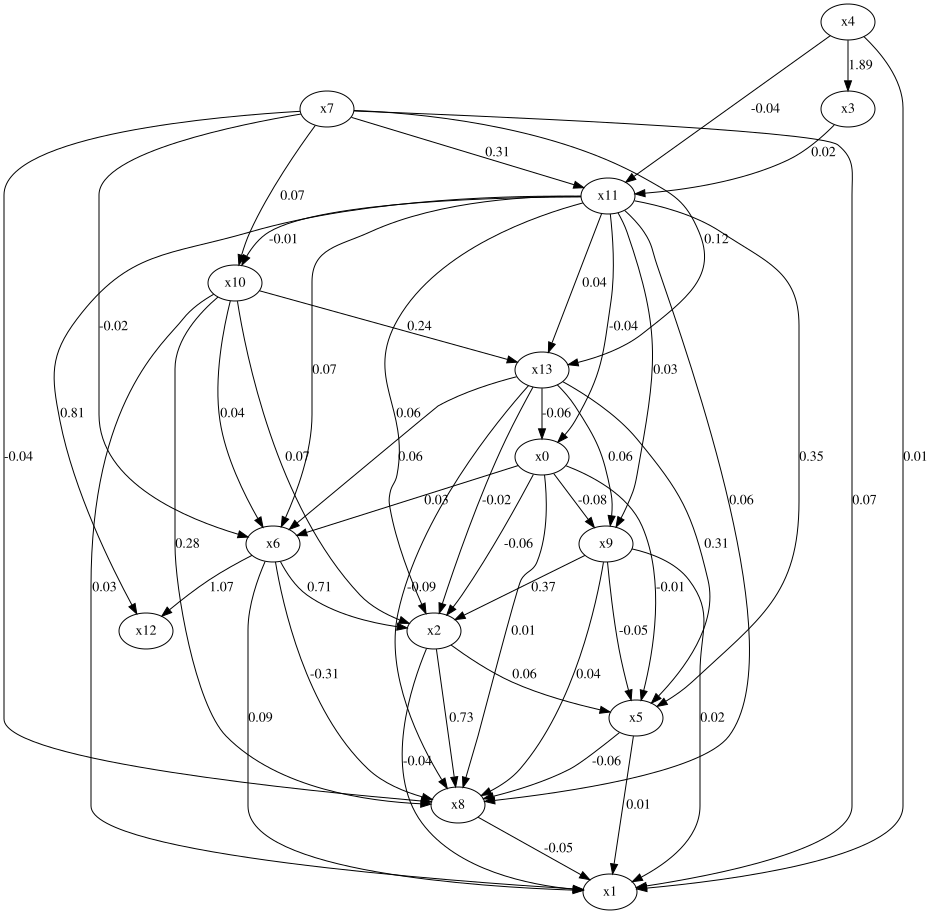

In [52]:
make_dot(adjacency_matrix)

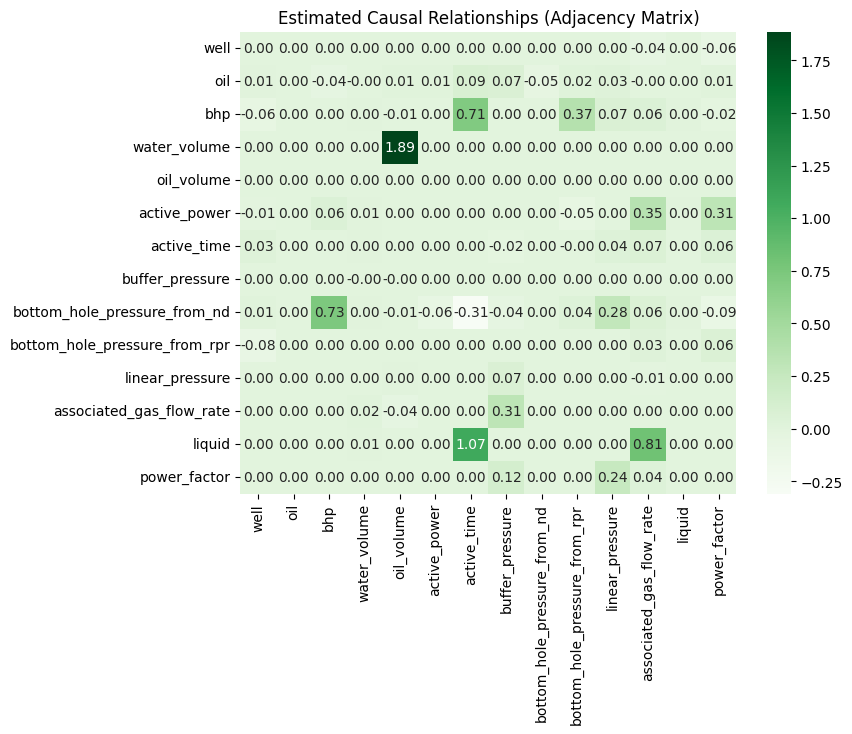

In [53]:
#Визуализируем в виде матрицы
adjacency_df = pd.DataFrame(adjacency_matrix, index=X.columns, columns=X.columns)

plt.figure(figsize=(8, 6))
sns.heatmap(adjacency_df, annot=True, cmap="Greens", fmt=".2f")
plt.title("Estimated Causal Relationships (Adjacency Matrix)")
plt.show()

При помощи линейной регрессии находим наиболее влияющий фактор

In [54]:
target = 1
features = [i for i in range(X.shape[1]) if i != target]
reg = LinearRegression()
reg.fit(X.iloc[:, features], X.iloc[:, target])

LinearRegression()

In [55]:
ce = lingam.CausalEffect(model)
effects = ce.estimate_effects_on_prediction(X, target, reg)

df_effects = pd.DataFrame()
df_effects['feature'] = X.columns
df_effects['effect'] = effects[:, 0]
df_effects

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/

,feature,effect
0,well,0.355435
1,oil,0.000000
2,bhp,1.959839
3,water_volume,0.510479
4,oil_volume,0.976913
5,active_power,0.607396
6,active_time,0.412993
7,buffer_pressure,0.498946
8,bottom_hole_pressure_from_nd,1.360896
9,bottom_hole_pressure_from_rpr,0.352142


In [56]:
max_index = np.unravel_index(np.argmax(effects), effects.shape)
print(X.columns[max_index[0]])

bhp


#Прогнозирование временных рядов

In [57]:
ITMO_data.set_index('date', inplace= True)
train, test = train_test_split(ITMO_data, test_size=0.3, random_state=2)
train.shape, test.shape
display(train.head())

,cat,oil,bhp,Объем жидкости,Объем нефти,Активная мощность (ТМ),Время работы (ТМ),Газовый фактор рабочий (ТМ),Давление буферное,Давление забойное от Hд,Давление забойное от Pпр,Давление линейное (ТМ),Давление на входе ЭЦН (ТМ),gas,Дебит газа попутного,liquid,Коэффициент мощности (ТМ),group,choke
date,,,,,,,,,,,,,,,,,,,
1991-10-19,p_75,14.262,55.950990,NaN,NaN,43.989231,21.267222,271.260,NaN,55.950990,NaN,18.501587,NaN,3221.235000,17.80,17.800000,65.318182,P,1
1991-07-21,p_63,8.444,132.917879,NaN,NaN,50.603061,15.270833,NaN,NaN,132.917879,NaN,16.252065,NaN,14380.563333,38.37,38.366667,75.500000,P,1
1990-08-01,p_89,11.563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P,1
1990-09-26,p_65,10.373,43.637233,NaN,NaN,59.893939,7.206667,338.353,19.0,34.938249,43.637233,1.766510,34.930070,NaN,15.67,15.666667,59.757576,P,1
1991-05-28,p_41,15.441,30.827907,NaN,NaN,37.362637,12.840278,NaN,NaN,30.827907,56.779799,16.612732,50.039249,2909.166667,21.45,21.450000,81.119565,P,1


In [59]:
train['oil'].mean()

10.801820604549796

In [177]:
def arima_forecast(train, test, order=(5, 1, 5)):
    model = ARIMA(train, order=order)
    model_fit = model.fit()
    predictions = model_fit.predict(start=len(train), end=len(train.index)-1)
    rmse = sqrt(root_mean_squared_error(test, predictions))
    mae = sqrt(mean_absolute_error(test, predictions))
    return predictions, rmse, mae

predictions_arima, rmse_arima, mae_arima = arima_forecast(train['oil'], test['oil'])
print(f'ARIMA RMSE: {rmse_arima:.2f}')
print(f'ARIMA MAE: {mae_arima:.2f}')
print(f'ARIMA PREDICTIONS: {predictions_arima:.2f}')

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsm

ValueError: Prediction must have `end` after `start`.